## Đọc và Tiền xử lý Dữ liệu



In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Re-check the base path and load the data
base_path = '/content/drive/MyDrive/active-learning-VietBioNER/dataset/preprocessed/'
train_file = os.path.join(base_path, 'train_segmented.txt')
dev_file = os.path.join(base_path, 'dev_segmented.txt')
test_file = os.path.join(base_path, 'test_segmented.txt')

def read_conll(file_path):
    sentences = []
    current_sentence = []
    if not os.path.exists(file_path):
        print(f"Warning: File {file_path} not found.")
        return []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    word = parts[0]
                    label = parts[-1]
                    current_sentence.append((word, label))
        if current_sentence:
            sentences.append(current_sentence)
    return sentences

train_data = read_conll(train_file)
dev_data = read_conll(dev_file)
test_data = read_conll(test_file)

print(f"Loaded {len(train_data)} sentences for training.")
print(f"Loaded {len(dev_data)} sentences for development.")
print(f"Loaded {len(test_data)} sentences for testing.")

if train_data:
    print("\nSample from training data:")
    for word, label in train_data[0][:10]:
        print(f"{word}\t{label}")

Mounted at /content/drive
Loaded 1089 sentences for training.
Loaded 136 sentences for development.
Loaded 137 sentences for testing.

Sample from training data:
[	O
22	O
]	O
Lao	B-Symptom_and_Disease
và	O
HIV	B-Symptom_and_Disease
/	I-Symptom_and_Disease
AIDS	I-Symptom_and_Disease
là	O
hai	O


## Thống kê Chi tiết Dataset


In [3]:
def get_stats(data, split_name):
    num_sentences = len(data)
    num_tokens = sum(len(s) for s in data)
    avg_len = num_tokens / num_sentences if num_sentences > 0 else 0

    all_labels = [label for s in data for _, label in s]
    entity_labels = [l for l in all_labels if l != 'O']
    num_entities = len([l for l in entity_labels if l.startswith('B-')])

    return {
        'Split': split_name,
        'Sentences': num_sentences,
        'Tokens': num_tokens,
        'Avg. Sentence Length': round(avg_len, 2),
        'Entity Mentions': num_entities
    }

stats_list = [
    get_stats(train_data, 'Train'),
    get_stats(dev_data, 'Dev'),
    get_stats(test_data, 'Test')
]

stats_df = pd.DataFrame(stats_list)
print("Dataset Descriptive Statistics:")
display(stats_df)

Dataset Descriptive Statistics:


,Split,Sentences,Tokens,Avg. Sentence Length,Entity Mentions
0,Train,1089,34106,31.32,2565
1,Dev,136,4320,31.76,320
2,Test,137,4090,29.85,314


## Trực quan hóa Phân phối Nhãn


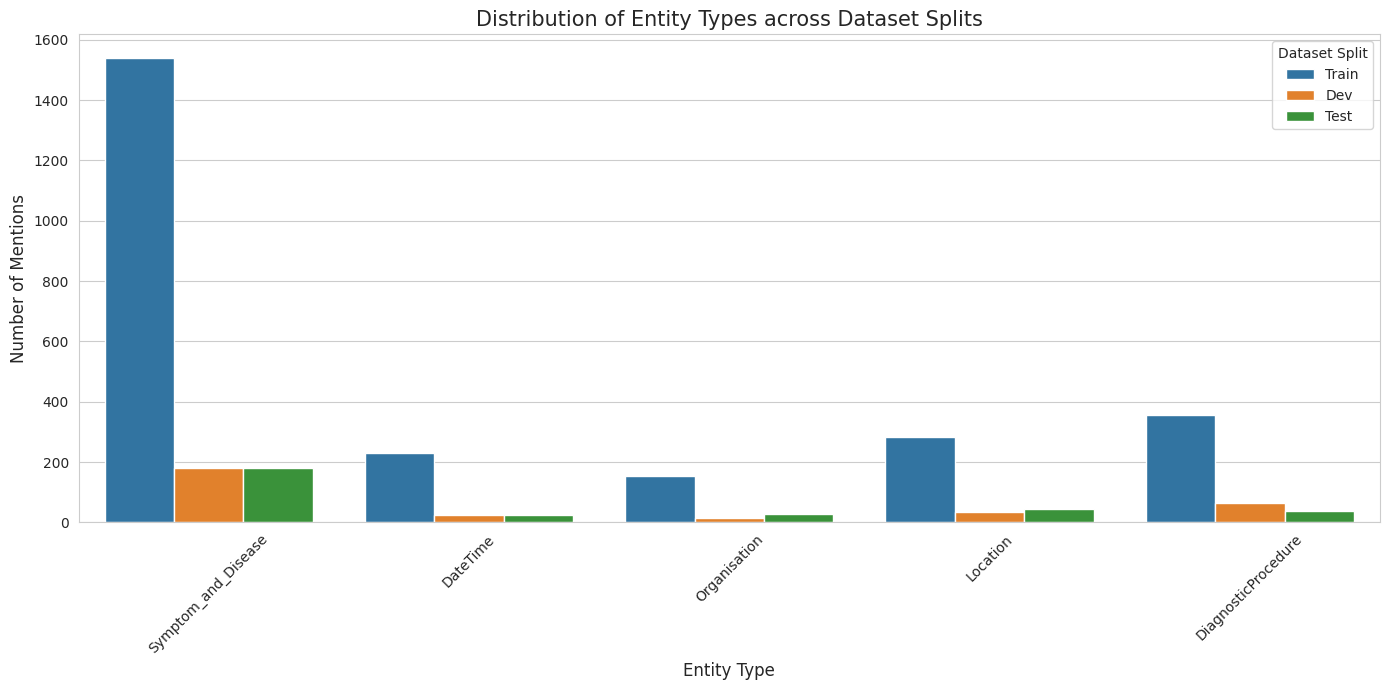

Label counts per split:


Split,Dev,Test,Train
Entity Type,,,
DateTime,26,23,231
DiagnosticProcedure,63,38,356
Location,36,45,283
Organisation,16,27,154
Symptom_and_Disease,179,181,1541


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

def count_entity_types(data, split_name):
    # Extract entity types from B- labels (e.g., 'B-Symptom' -> 'Symptom')
    entities = [label.split('-', 1)[1] for s in data for _, label in s if label.startswith('B-')]
    counts = Counter(entities)
    return [{'Entity Type': k, 'Count': v, 'Split': split_name} for k, v in counts.items()]

# Aggregate data for plotting
all_counts = []
all_counts.extend(count_entity_types(train_data, 'Train'))
all_counts.extend(count_entity_types(dev_data, 'Dev'))
all_counts.extend(count_entity_types(test_data, 'Test'))

label_counts_df = pd.DataFrame(all_counts)

# Visualization
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
ax = sns.barplot(data=label_counts_df, x='Entity Type', y='Count', hue='Split')

plt.title('Distribution of Entity Types across Dataset Splits', fontsize=15)
plt.xlabel('Entity Type', fontsize=12)
plt.ylabel('Number of Mentions', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Dataset Split')
plt.tight_layout()
plt.show()

print("Label counts per split:")
display(label_counts_df.pivot(index='Entity Type', columns='Split', values='Count').fillna(0).astype(int))

## Trực quan hóa Độ dài Câu


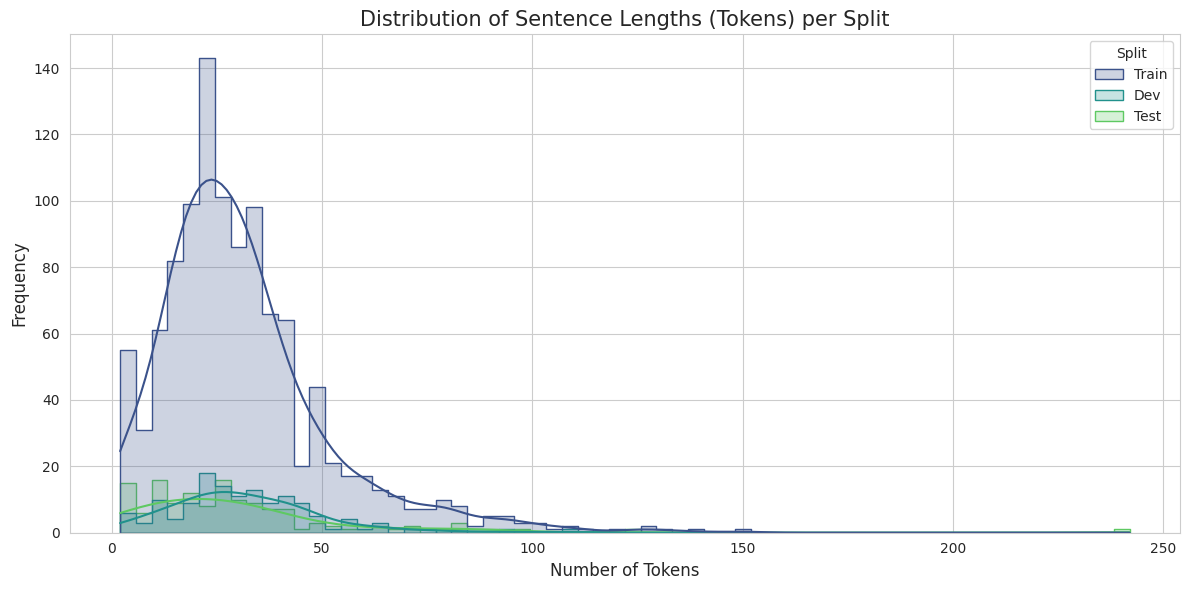

Sentence Length Descriptive Statistics:


,count,min,max,mean,median,std
Split,,,,,,
Dev,136,2,110,31.76,29.5,17.88
Test,137,2,242,29.85,25.0,28.85
Train,1089,2,150,31.32,28.0,20.35


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate sentence lengths for each split
def get_sentence_lengths(data, split_name):
    lengths = [len(s) for s in data]
    return pd.DataFrame({'Length': lengths, 'Split': split_name})

train_lengths = get_sentence_lengths(train_data, 'Train')
dev_lengths = get_sentence_lengths(dev_data, 'Dev')
test_lengths = get_sentence_lengths(test_data, 'Test')

# Combine into one DataFrame
all_lengths_df = pd.concat([train_lengths, dev_lengths, test_lengths], ignore_index=True)

# 2. Visualize Sentence Length Distribution
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.histplot(data=all_lengths_df, x='Length', hue='Split', kde=True, element="step", palette='viridis')

plt.title('Distribution of Sentence Lengths (Tokens) per Split', fontsize=15)
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Basic Statistics for Sentence Lengths
summary_stats = all_lengths_df.groupby('Split')['Length'].agg(['count', 'min', 'max', 'mean', 'median', 'std']).round(2)
print("Sentence Length Descriptive Statistics:")
display(summary_stats)